In [1]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# grab NLTK data if it's not cached already
for resource in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(resource, quiet=True)

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print("All imports successful.")

TensorFlow: 2.21.0
All imports successful.


In [2]:
# absolute path — works regardless of where VS Code launched the kernel
BASE_DIR = "/Users/manishabista/Desktop/Coursework AIML"
CSV_PATH = os.path.join(BASE_DIR, "9.Spam vs Ham Sms Dataset", "spamvsham.csv")

# the CSV has extra empty columns — just keep the first two
df = pd.read_csv(CSV_PATH, encoding='latin-1').iloc[:, :2]
df.columns = ['label', 'text']
df = df.dropna(subset=['label', 'text'])

print(f"Rows: {len(df)}")
print(f"Label counts:\n{df['label'].value_counts()}")
print(f"\nClass balance: {df['label'].value_counts(normalize=True).round(3).to_dict()}")
print(f"\nFirst few rows:")
print(df.head(5).to_string())

Rows: 5572
Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Class balance: {'ham': 0.866, 'spam': 0.134}

First few rows:
  label                                                                                                                                                         text
0   ham                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
1   ham                                                                                                                                Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3   ham                                                                                                            U dun say so early hor... U c already then say...
4   ham                      

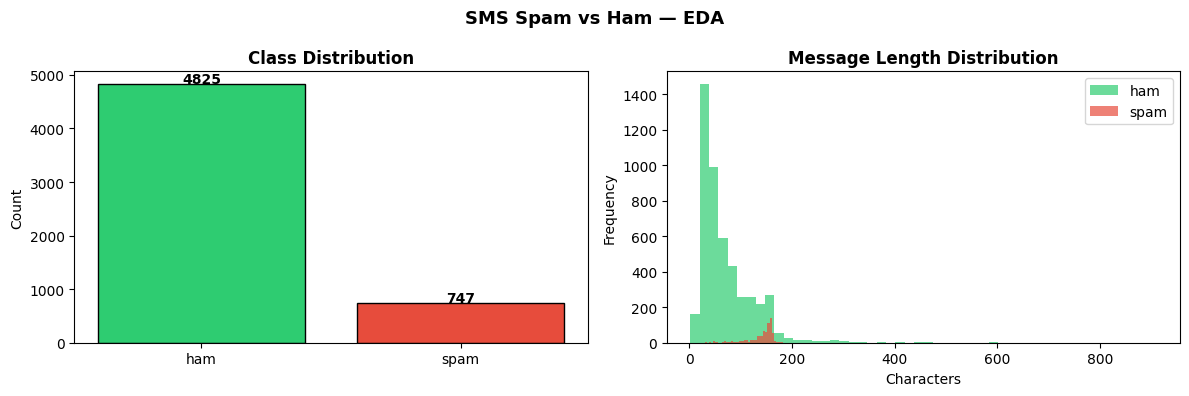

Spam messages are typically longer than ham messages.


In [3]:
df['label_enc'] = (df['label'] == 'spam').astype(int)

plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ECC71', '#E74C3C'], edgecolor='black')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
df['msg_len'] = df['text'].str.len()
for label, color in [('ham', '#2ECC71'), ('spam', '#E74C3C')]:
    axes[1].hist(df[df['label'] == label]['msg_len'], bins=50, alpha=0.7, label=label, color=color)
axes[1].set_title('Message Length Distribution', fontweight='bold')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')
axes[1].legend()
fig.suptitle('SMS Spam vs Ham — EDA', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(BASE_DIR, 'nlp_eda.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Spam messages are typically longer than ham messages.')


In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# common contractions that tokenisers handle poorly — expand them first
CONTRACTIONS = {
    "don't": "do not", "won't": "will not", "can't": "cannot",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "it's": "it is", "that's": "that is",
    "there's": "there is", "they're": "they are", "we're": "we are",
    "n't": " not", "'re": " are", "'ve": " have", "'ll": " will", "'d": " would",
}

def clean_text(text):
    text = text.lower()
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    text = re.sub(r'http\S+|www\S+', '', text)      # strip URLs
    text = re.sub(r'@\w+|#\w+', '', text)            # strip @mentions and #hashtags
    text = re.sub(r'\d+', '', text)                   # remove numbers
    text = re.sub(r'[^a-z\s]', ' ', text)             # keep only letters and spaces
    tokens = [lemmatizer.lemmatize(t)
              for t in text.split()
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

print("Before and after cleaning:")
for i in range(3):
    print(f"\n  Original : {df['text'].iloc[i]}")
    print(f"  Cleaned  : {df['clean_text'].iloc[i]}")

Before and after cleaning:

  Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  Cleaned  : jurong point crazy available bugis great world buffet cine got amore wat

  Original : Ok lar... Joking wif u oni...
  Cleaned  : lar joking wif oni

  Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  Cleaned  : free entry wkly comp win cup final tkts may text receive entry question std txt rate apply


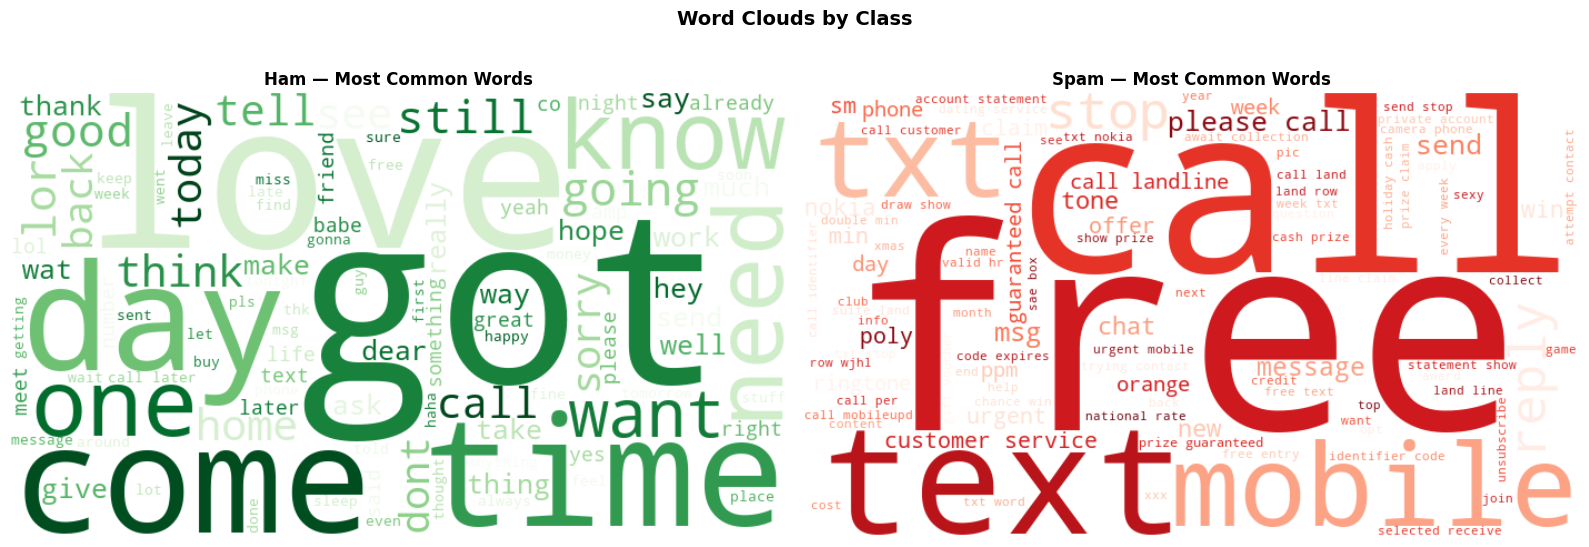

In [5]:
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label, cmap, title in [
    (axes[0], 'ham',  'Greens', 'Ham — Most Common Words'),
    (axes[1], 'spam', 'Reds',   'Spam — Most Common Words'),
]:
    text = ' '.join(df[df['label'] == label]['clean_text'])
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=12)
fig.suptitle('Word Clouds by Class', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(BASE_DIR, 'wordclouds.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)


In [6]:
VOCAB_SIZE = 10000   # top 10k words — covers the meaningful vocabulary easily
EMBED_DIM  = 64

X = df['clean_text'].values
y = df['label_enc'].values

# stratify keeps the 87/13 ham/spam ratio intact in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

# fit the tokeniser on training data only — no data leakage
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
print(f'Unique tokens in training vocab: {len(tokenizer.word_index):,}')

# BUG FIX: derive MAX_LEN from the actual data instead of hardcoding 150.
# The original value of 150 was ~8x too large (95th percentile is only ~17 tokens),
# meaning ~90% of each padded sequence was zeros — RNNs drowned in padding noise
# and could not learn, causing all models to collapse to the majority class.
train_lengths = [len(t.split()) for t in X_train]
p95 = int(np.percentile(train_lengths, 95))
MAX_LEN = p95 + 5   # small buffer above 95th percentile
print(f'95th percentile token length: {p95}')
print(f'MAX_LEN set to: {MAX_LEN}  (was hardcoded 150 — bug fixed)')

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nX_train shape: {X_train_seq.shape}')
print(f'X_test shape : {X_test_seq.shape}')

# keep word_index around — the GloVe model needs it to build the embedding matrix
word_index = tokenizer.word_index


Train: 4457  |  Test: 1115
Unique tokens in training vocab: 6,064
95th percentile token length: 17
MAX_LEN set to: 22  (was hardcoded 150 — bug fixed)

X_train shape: (4457, 22)
X_test shape : (1115, 22)


In [7]:
# Model 1: a basic RNN — simple baseline, struggles with long-range context
rnn_model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    # mask_zero=True tells the RNN to skip padding positions (index 0)
    # so it only processes real tokens — critical for variable-length SMS text
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     mask_zero=True, name='embedding_rnn'),
    layers.SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
], name='Simple_RNN')

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ (None, 22, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Model 2: Bidirectional LSTM — reads each message forwards AND backwards
# so it captures context from both directions, improving on SimpleRNN
lstm_model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     mask_zero=True, name='embedding_lstm'),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True,
                                     dropout=0.2, recurrent_dropout=0.2)),
    layers.Bidirectional(layers.LSTM(32, dropout=0.2)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
], name='BiLSTM_Trainable_Embedding')

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()


Model: "BiLSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ (None, 22, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 22, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 749,377 (2.86 MB)

 Trainable params: 749,377 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Model 3: standard LSTM with frozen GloVe embeddings.
# Pretrained GloVe vectors give the model semantic knowledge from day one —
# it already knows that 'free', 'win', 'prize' are related before any training.

import gensim.downloader as api
print('Downloading GloVe 50d vectors (this takes a few minutes on first run)...')
glove = api.load('glove-wiki-gigaword-50')
print('GloVe loaded.')

W2V_DIM = 50
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
found = 0
for word, idx in word_index.items():
    if idx < VOCAB_SIZE and word in glove:
        embedding_matrix[idx] = glove[word]
        found += 1

print(f'Coverage: {found:,} / {min(VOCAB_SIZE, len(word_index)):,} words found in GloVe')

lstm_w2v_model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=W2V_DIM,
                     weights=[embedding_matrix],
                     trainable=False,       # keep GloVe weights frozen
                     mask_zero=True,        # skip padding positions
                     name='embedding_glove'),
    layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    layers.LSTM(32, dropout=0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
], name='LSTM_GloVe')

lstm_w2v_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_w2v_model.summary()


GloVe loaded.
Coverage: 4,934 / 6,064 words found in GloVe


Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove (Embedding)     │ (None, 22, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 22, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,945 (2.07 MB)

 Trainable params: 42,945 (167.75 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [10]:
# class_weight corrects for the 87/13 ham/spam imbalance.
# Without it every model collapses to always predicting 'ham'.
n_neg, n_pos = np.bincount(y_train)          # ham count, spam count
class_weight = {0: 1.0, 1: n_neg / n_pos}    # penalise missing spam more
print(f'Class weights — ham: 1.0  |  spam: {n_neg/n_pos:.2f}')

histories   = {}
train_times = {}

for name, model in [('Simple RNN',  rnn_model),
                    ('BiLSTM',       lstm_model),
                    ('LSTM+GloVe',   lstm_w2v_model)]:
    print(f'\nTraining: {name}')
    print('-' * 40)

    # BUG FIX: create a FRESH EarlyStopping for every model.
    # Reusing one object carries stale state (best score, wait counter)
    # from the previous model, causing models 2 and 3 to stop too early.
    early_stop = EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True, verbose=1)

    start = time.time()
    h = model.fit(
        X_train_seq, y_train,
        validation_split=0.1,
        epochs=20,
        batch_size=64,
        callbacks=[early_stop],
        class_weight=class_weight,
        verbose=1,
    )
    histories[name]   = h
    train_times[name] = time.time() - start
    print(f'{name} done in {train_times[name]:.1f}s')


Class weights — ham: 1.0  |  spam: 6.45

Training: Simple RNN
----------------------------------------
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5889 - loss: 1.0865 - val_accuracy: 0.8498 - val_loss: 0.5948
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9180 - loss: 0.5882 - val_accuracy: 0.9350 - val_loss: 0.2921
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9691 - loss: 0.2850 - val_accuracy: 0.9596 - val_loss: 0.1728
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9825 - loss: 0.1476 - val_accuracy: 0.9619 - val_loss: 0.1421
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9895 - loss: 0.0877 - val_accuracy: 0.9664 - val_loss: 0.1162
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9910 - loss: 0.0596 - val_accuracy: 0.9664 - val_loss: 0.1379
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9920 - loss: 0.0603 - val_accuracy: 0.9664 - val_loss: 0.1459
Epoch 8/20
63/6

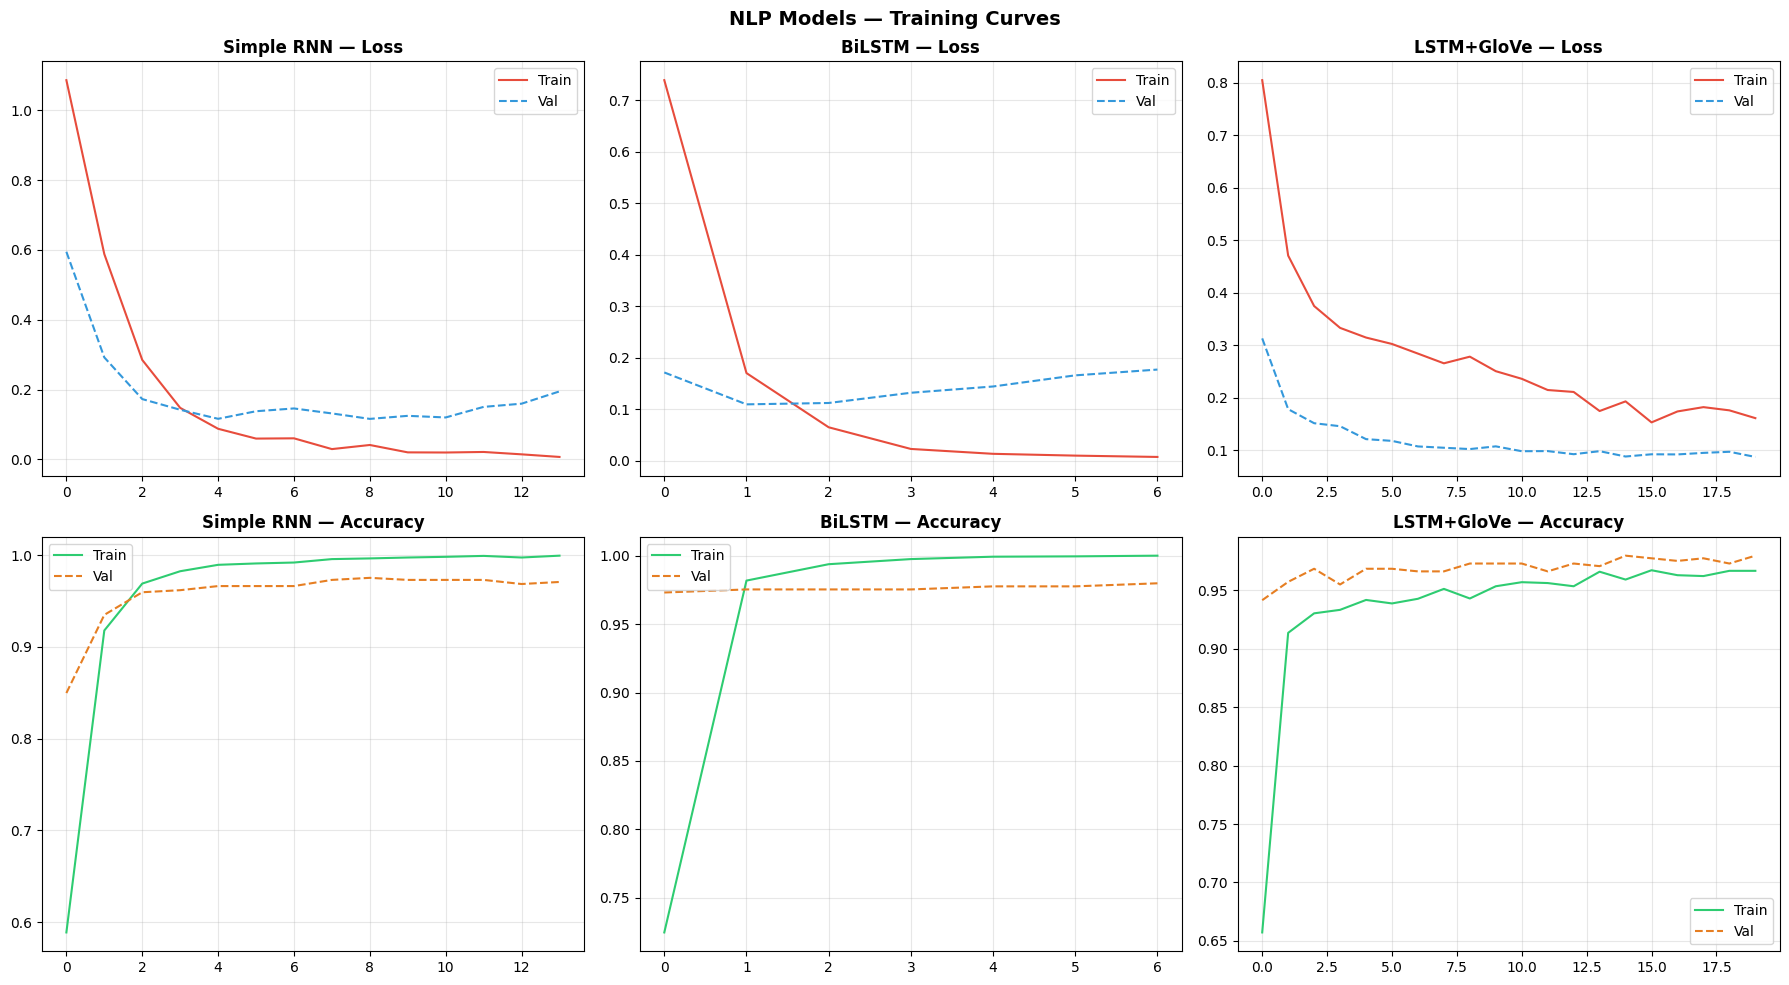

In [11]:
plt.close('all')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, (name, h) in enumerate(histories.items()):
    axes[0][col].plot(h.history['loss'],     label='Train', color='#E74C3C')
    axes[0][col].plot(h.history['val_loss'], label='Val',   color='#3498DB', linestyle='--')
    axes[0][col].set_title(f'{name} — Loss', fontweight='bold')
    axes[0][col].legend(); axes[0][col].grid(alpha=0.3)
    axes[1][col].plot(h.history['accuracy'],     label='Train', color='#2ECC71')
    axes[1][col].plot(h.history['val_accuracy'], label='Val',   color='#E67E22', linestyle='--')
    axes[1][col].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[1][col].legend(); axes[1][col].grid(alpha=0.3)
fig.suptitle('NLP Models — Training Curves', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(BASE_DIR, 'nlp_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)



Simple RNN
Accuracy: 0.9722  (97.22%)
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98       966
        Spam       0.87      0.93      0.90       149

    accuracy                           0.97      1115
   macro avg       0.93      0.96      0.94      1115
weighted avg       0.97      0.97      0.97      1115

Saved: /Users/manishabista/Desktop/Coursework AIML/nlp_Simple_RNN_cm.png


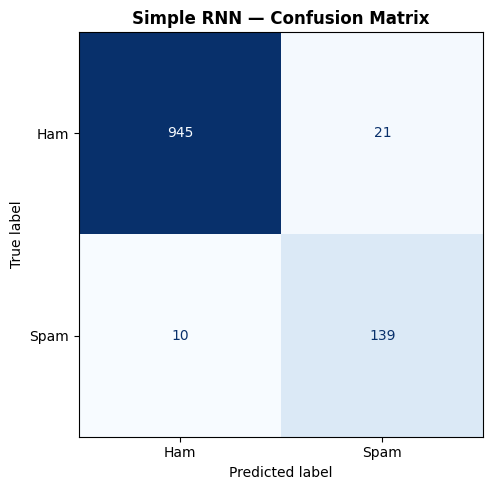


BiLSTM
Accuracy: 0.9794  (97.94%)
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.93      0.92      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



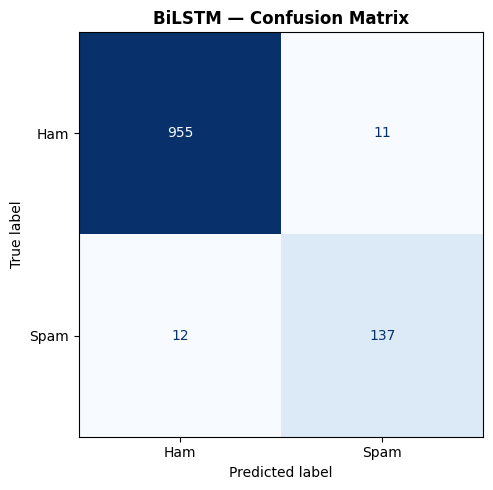


LSTM+GloVe
Accuracy: 0.9695  (96.95%)
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98       966
        Spam       0.85      0.94      0.89       149

    accuracy                           0.97      1115
   macro avg       0.92      0.96      0.94      1115
weighted avg       0.97      0.97      0.97      1115

Saved: /Users/manishabista/Desktop/Coursework AIML/nlp_LSTM+GloVe_cm.png


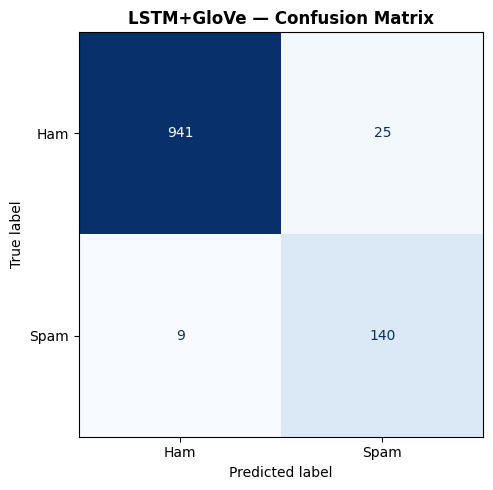

In [12]:
def evaluate_nlp_model(model, X_test, y_test, name):
    probs = model.predict(X_test, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)
    acc   = accuracy_score(y_test, preds)

    print(f'\n{name}')
    print('=' * 50)
    print(f'Accuracy: {acc:.4f}  ({acc*100:.2f}%)')
    print(classification_report(y_test, preds, target_names=['Ham', 'Spam']))

    plt.close('all')  # close any lingering figures before creating a new one
    cm = confusion_matrix(y_test, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    fig.tight_layout()
    save_path = os.path.join(BASE_DIR, f'nlp_{name.replace(" ", "_")}_cm.png')
    try:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')  # use fig.savefig, not plt.savefig
        print(f'Saved: {save_path}')
    except PermissionError:
        print(f'Warning: could not save {save_path} — file may be open elsewhere')
    plt.show()
    plt.close(fig)  # release figure memory after displaying
    return acc, preds

nlp_results = {}
for name, model in [('Simple RNN',  rnn_model),
                    ('BiLSTM',       lstm_model),
                    ('LSTM+GloVe',   lstm_w2v_model)]:
    acc, preds = evaluate_nlp_model(model, X_test_seq, y_test, name)
    nlp_results[name] = {'acc': acc, 'preds': preds}


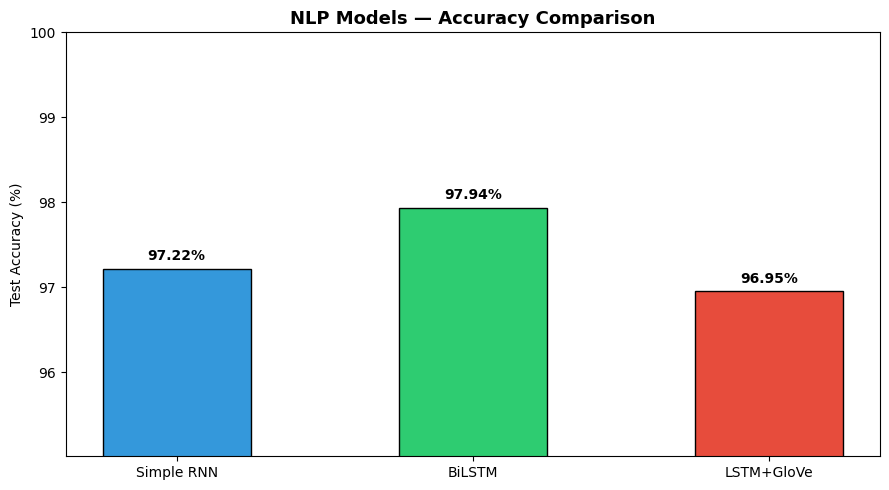

In [13]:
plt.close('all')
fig, ax = plt.subplots(figsize=(9, 5))
names = list(nlp_results.keys())
accs  = [v['acc'] * 100 for v in nlp_results.values()]
bars  = ax.bar(names, accs, color=['#3498DB', '#2ECC71', '#E74C3C'],
               edgecolor='black', width=0.5)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('NLP Models — Accuracy Comparison', fontweight='bold', fontsize=13)
ax.set_ylim(min(accs) * 0.98, 100)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(BASE_DIR, 'nlp_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)


In [14]:
# find where the best model went wrong and try to understand why
best_name  = max(nlp_results, key=lambda k: nlp_results[k]['acc'])
best_preds = nlp_results[best_name]['preds']
print(f'Analysing errors from: {best_name}')

wrong_idx = np.where(best_preds != y_test)[0]
print(f'\nMisclassified: {len(wrong_idx)} out of {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f}%)')

print('\n--- 3 Misclassified Examples ---')
for i, idx in enumerate(wrong_idx[:3]):
    true  = 'spam' if y_test[idx] == 1 else 'ham'
    pred  = 'spam' if best_preds[idx] == 1 else 'ham'
    print(f'\n[{i+1}] Message  : {X_test[idx]}')
    print(f'     True label: {true}')
    print(f'     Predicted : {pred}')

print('\nWhy does the model get these wrong?')
print('  1. Short or ambiguous messages with casual language look like ham even when spam.')
print('  2. Spam that deliberately misspells trigger words to evade detection.')
print('  3. Genuine ham messages about offers or deals share vocabulary with spam.')

print('\nHow could we improve this?')
print('  - Use character-level features to handle misspellings and obfuscation.')
print('  - Fine-tune a BERT model — its contextual embeddings understand nuance much better.')
print('  - Apply class weighting to give more importance to the minority spam class.')
print('  - Increase training data using augmentation on the spam class.')


Analysing errors from: BiLSTM

Misclassified: 23 out of 1115 (2.1%)

--- 3 Misclassified Examples ---

[1] Message  : freemsg hey darling week word back would like fun still xxx std chgs send rcv
     True label: spam
     Predicted : ham

[2] Message  : one day crab running sea shore wave came cleared footprint crab crab asked frnd clearing beautiful footprint wave replied fox following footprint catch thats cleared frndsship never let dwn gud nyt
     True label: ham
     Predicted : spam

[3] Message  : call waiting call
     True label: ham
     Predicted : spam

Why does the model get these wrong?
  1. Short or ambiguous messages with casual language look like ham even when spam.
  2. Spam that deliberately misspells trigger words to evade detection.
  3. Genuine ham messages about offers or deals share vocabulary with spam.

How could we improve this?
  - Use character-level features to handle misspellings and obfuscation.
  - Fine-tune a BERT model — its contextual embeddings un

In [15]:
import gradio as gr

# use whichever model scored best
best_model = {'Simple RNN': rnn_model, 'BiLSTM': lstm_model,
              'LSTM+GloVe': lstm_w2v_model}[best_name]

def predict_spam(message):
    cleaned = clean_text(message)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob    = float(best_model.predict(padded, verbose=0)[0][0])
    label   = 'SPAM' if prob >= 0.5 else 'HAM (legitimate)'
    conf    = prob if prob >= 0.5 else 1 - prob
    return f'Prediction: {label}\nConfidence: {conf*100:.1f}%\nSpam probability: {prob*100:.1f}%'

demo = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(lines=3, placeholder='Type or paste an SMS message...', label='Message'),
    outputs=gr.Textbox(label='Result'),
    title=f'SMS Spam Detector ({best_name})',
    description='6CS012 Final Portfolio | Herald College 2026 | Manisha Bista',
    examples=[
        ['Congratulations! You have won a FREE prize. Call now to claim!'],
        ['Are we still on for lunch tomorrow?'],
        ['URGENT: Your account has been compromised. Click here immediately.'],
        ['Can you pick up milk on the way home?'],
        ['FREE entry to win £1000 cash! Text WIN to 84888 now!'],
    ],
    theme='soft',
)

demo.launch(share=False, inbrowser=True)
# use share=True if running on Colab to get a public link


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
